# ⚖️ Notebook 03: Phân Tích Thuộc Tính Nhạy Cảm & Fairness Baseline

> **Mục tiêu**: Phân tích thuộc tính nhân khẩu học nhạy cảm (`customer_age`, `employment_status`, `income`) để đặt nền móng cho đánh giá tính công bằng (**Fairness-aware ML**) ở Tuần 5.


In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
PROJECT_ROOT = Path("..").resolve()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
BASE_PATH = RAW_DATA_DIR / "Base.csv"

df = pd.read_csv(BASE_PATH)
print(f"Base.csv loaded: {len(df):,} rows")


Base.csv loaded: 1,000,000 rows


## 1. Phân Nhóm Độ Tuổi (Age Bins) & Fraud Rate


--- Fraud Rate Theo Nhóm Tuổi ---
                age_group   count   sum      mean  fraud_rate_%
0               <25 (Trẻ)  266842  1279  0.004793      0.479310
1  25-40 (Trung niên trẻ)  550145  5465  0.009934      0.993374
2      40-60 (Trung niên)  175123  3954  0.022578      2.257842
3          >60 (Cao tuổi)    7890   331  0.041952      4.195184


/tmp/ipykernel_48137/2878748474.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_fairness = df.groupby('age_group')['fraud_bool'].agg(['count', 'sum', 'mean']).reset_index()
/tmp/ipykernel_48137/2878748474.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_fairness, x='age_group', y='fraud_rate_%', palette='viridis')


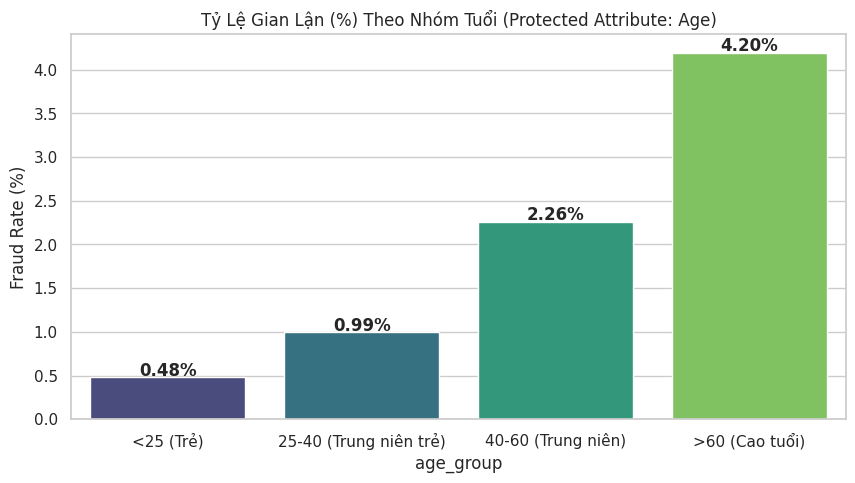

In [2]:
age_bins = [0, 25, 40, 60, 100]
age_labels = ['<25 (Trẻ)', '25-40 (Trung niên trẻ)', '40-60 (Trung niên)', '>60 (Cao tuổi)']
df['age_group'] = pd.cut(df['customer_age'], bins=age_bins, labels=age_labels)

age_fairness = df.groupby('age_group')['fraud_bool'].agg(['count', 'sum', 'mean']).reset_index()
age_fairness['fraud_rate_%'] = age_fairness['mean'] * 100

print("--- Fraud Rate Theo Nhóm Tuổi ---")
print(age_fairness)

plt.figure(figsize=(10, 5))
sns.barplot(data=age_fairness, x='age_group', y='fraud_rate_%', palette='viridis')
plt.title('Tỷ Lệ Gian Lận (%) Theo Nhóm Tuổi (Protected Attribute: Age)')
plt.ylabel('Fraud Rate (%)')
for i, row in age_fairness.iterrows():
    plt.text(i, row['fraud_rate_%'] + 0.02, f"{row['fraud_rate_%']:.2f}%", ha='center', fontweight='bold')
plt.show()


## 2. Phân Tích Tình Trạng Việc Làm (`employment_status`)


--- Fraud Rate Theo Tình Trạng Việc Làm ---
  employment_status   count   sum      mean  fraud_rate_%
2                CC   37758   932  0.024684      2.468351
6                CG     453     7  0.015453      1.545254
0                CA  730252  8899  0.012186      1.218620
1                CB  138288   953  0.006891      0.689142
3                CD   26522   100  0.003770      0.377045
4                CE   22693    53  0.002336      0.233552
5                CF   44034    85  0.001930      0.193033


/tmp/ipykernel_48137/3746834633.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=emp_fairness, x='employment_status', y='fraud_rate_%', palette='rocket')


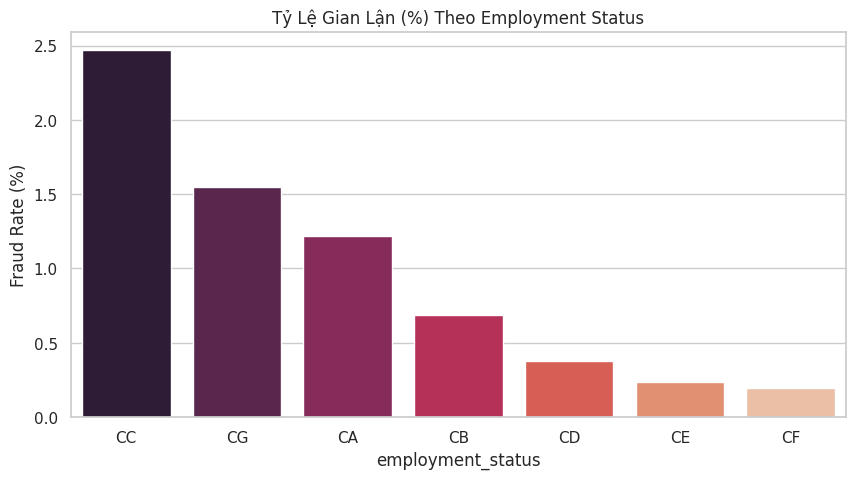

In [3]:
emp_fairness = df.groupby('employment_status')['fraud_bool'].agg(['count', 'sum', 'mean']).reset_index()
emp_fairness['fraud_rate_%'] = emp_fairness['mean'] * 100
emp_fairness = emp_fairness.sort_values(by='fraud_rate_%', ascending=False)

print("--- Fraud Rate Theo Tình Trạng Việc Làm ---")
print(emp_fairness)

plt.figure(figsize=(10, 5))
sns.barplot(data=emp_fairness, x='employment_status', y='fraud_rate_%', palette='rocket')
plt.title('Tỷ Lệ Gian Lận (%) Theo Employment Status')
plt.ylabel('Fraud Rate (%)')
plt.show()


## 3. Phân Tích Mức Thu Nhập (`income`)


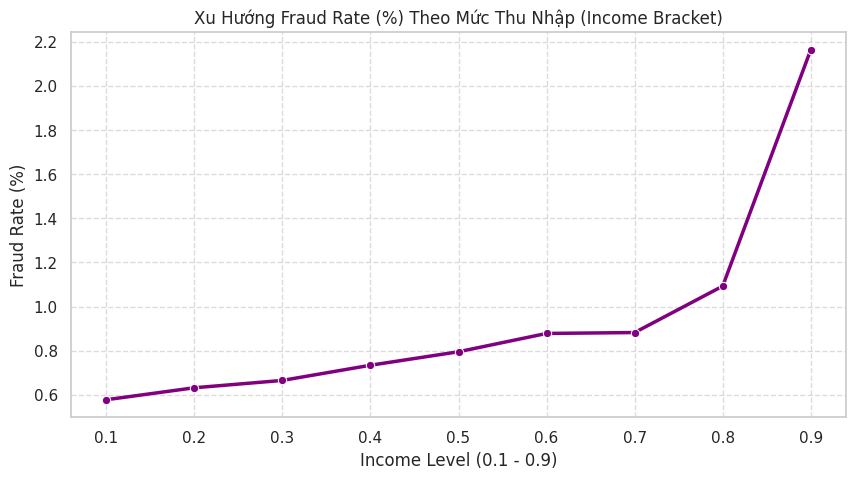

In [4]:
inc_fairness = df.groupby('income')['fraud_bool'].agg(['count', 'sum', 'mean']).reset_index()
inc_fairness['fraud_rate_%'] = inc_fairness['mean'] * 100

plt.figure(figsize=(10, 5))
sns.lineplot(data=inc_fairness, x='income', y='fraud_rate_%', marker='o', color='purple', linewidth=2.5)
plt.title('Xu Hướng Fraud Rate (%) Theo Mức Thu Nhập (Income Bracket)')
plt.xlabel('Income Level (0.1 - 0.9)')
plt.ylabel('Fraud Rate (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


## 4. Tổng Kết Phân Tích Fairness Cho Tuần 5
1. **Độ tuổi (`customer_age`)**: Có sự chênh lệch rõ rệt về tỷ lệ fraud thực tế giữa các nhóm tuổi.
2. **Tình trạng việc làm (`employment_status`)**: Một số nhóm việc làm có tỷ lệ gian lận cao hơn hẳn mặt bằng chung (1.1%).
3. **Thu nhập (`income`)**: Fraud rate thay đổi theo hạn mức thu nhập.
-> Đây sẽ là các protected attributes chính để đánh giá **Equal Opportunity Difference** và **Demographic Parity** ở **Tuần 5**.
